Downloading some libraries.

In [1]:
# Scikit-Learn ≥0.20 is required
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Reading the csv file using pandas, saving the data as a dataframe, and removing outlier values from the dataset to improve the performance of the models. 
Exploring the dataset. 

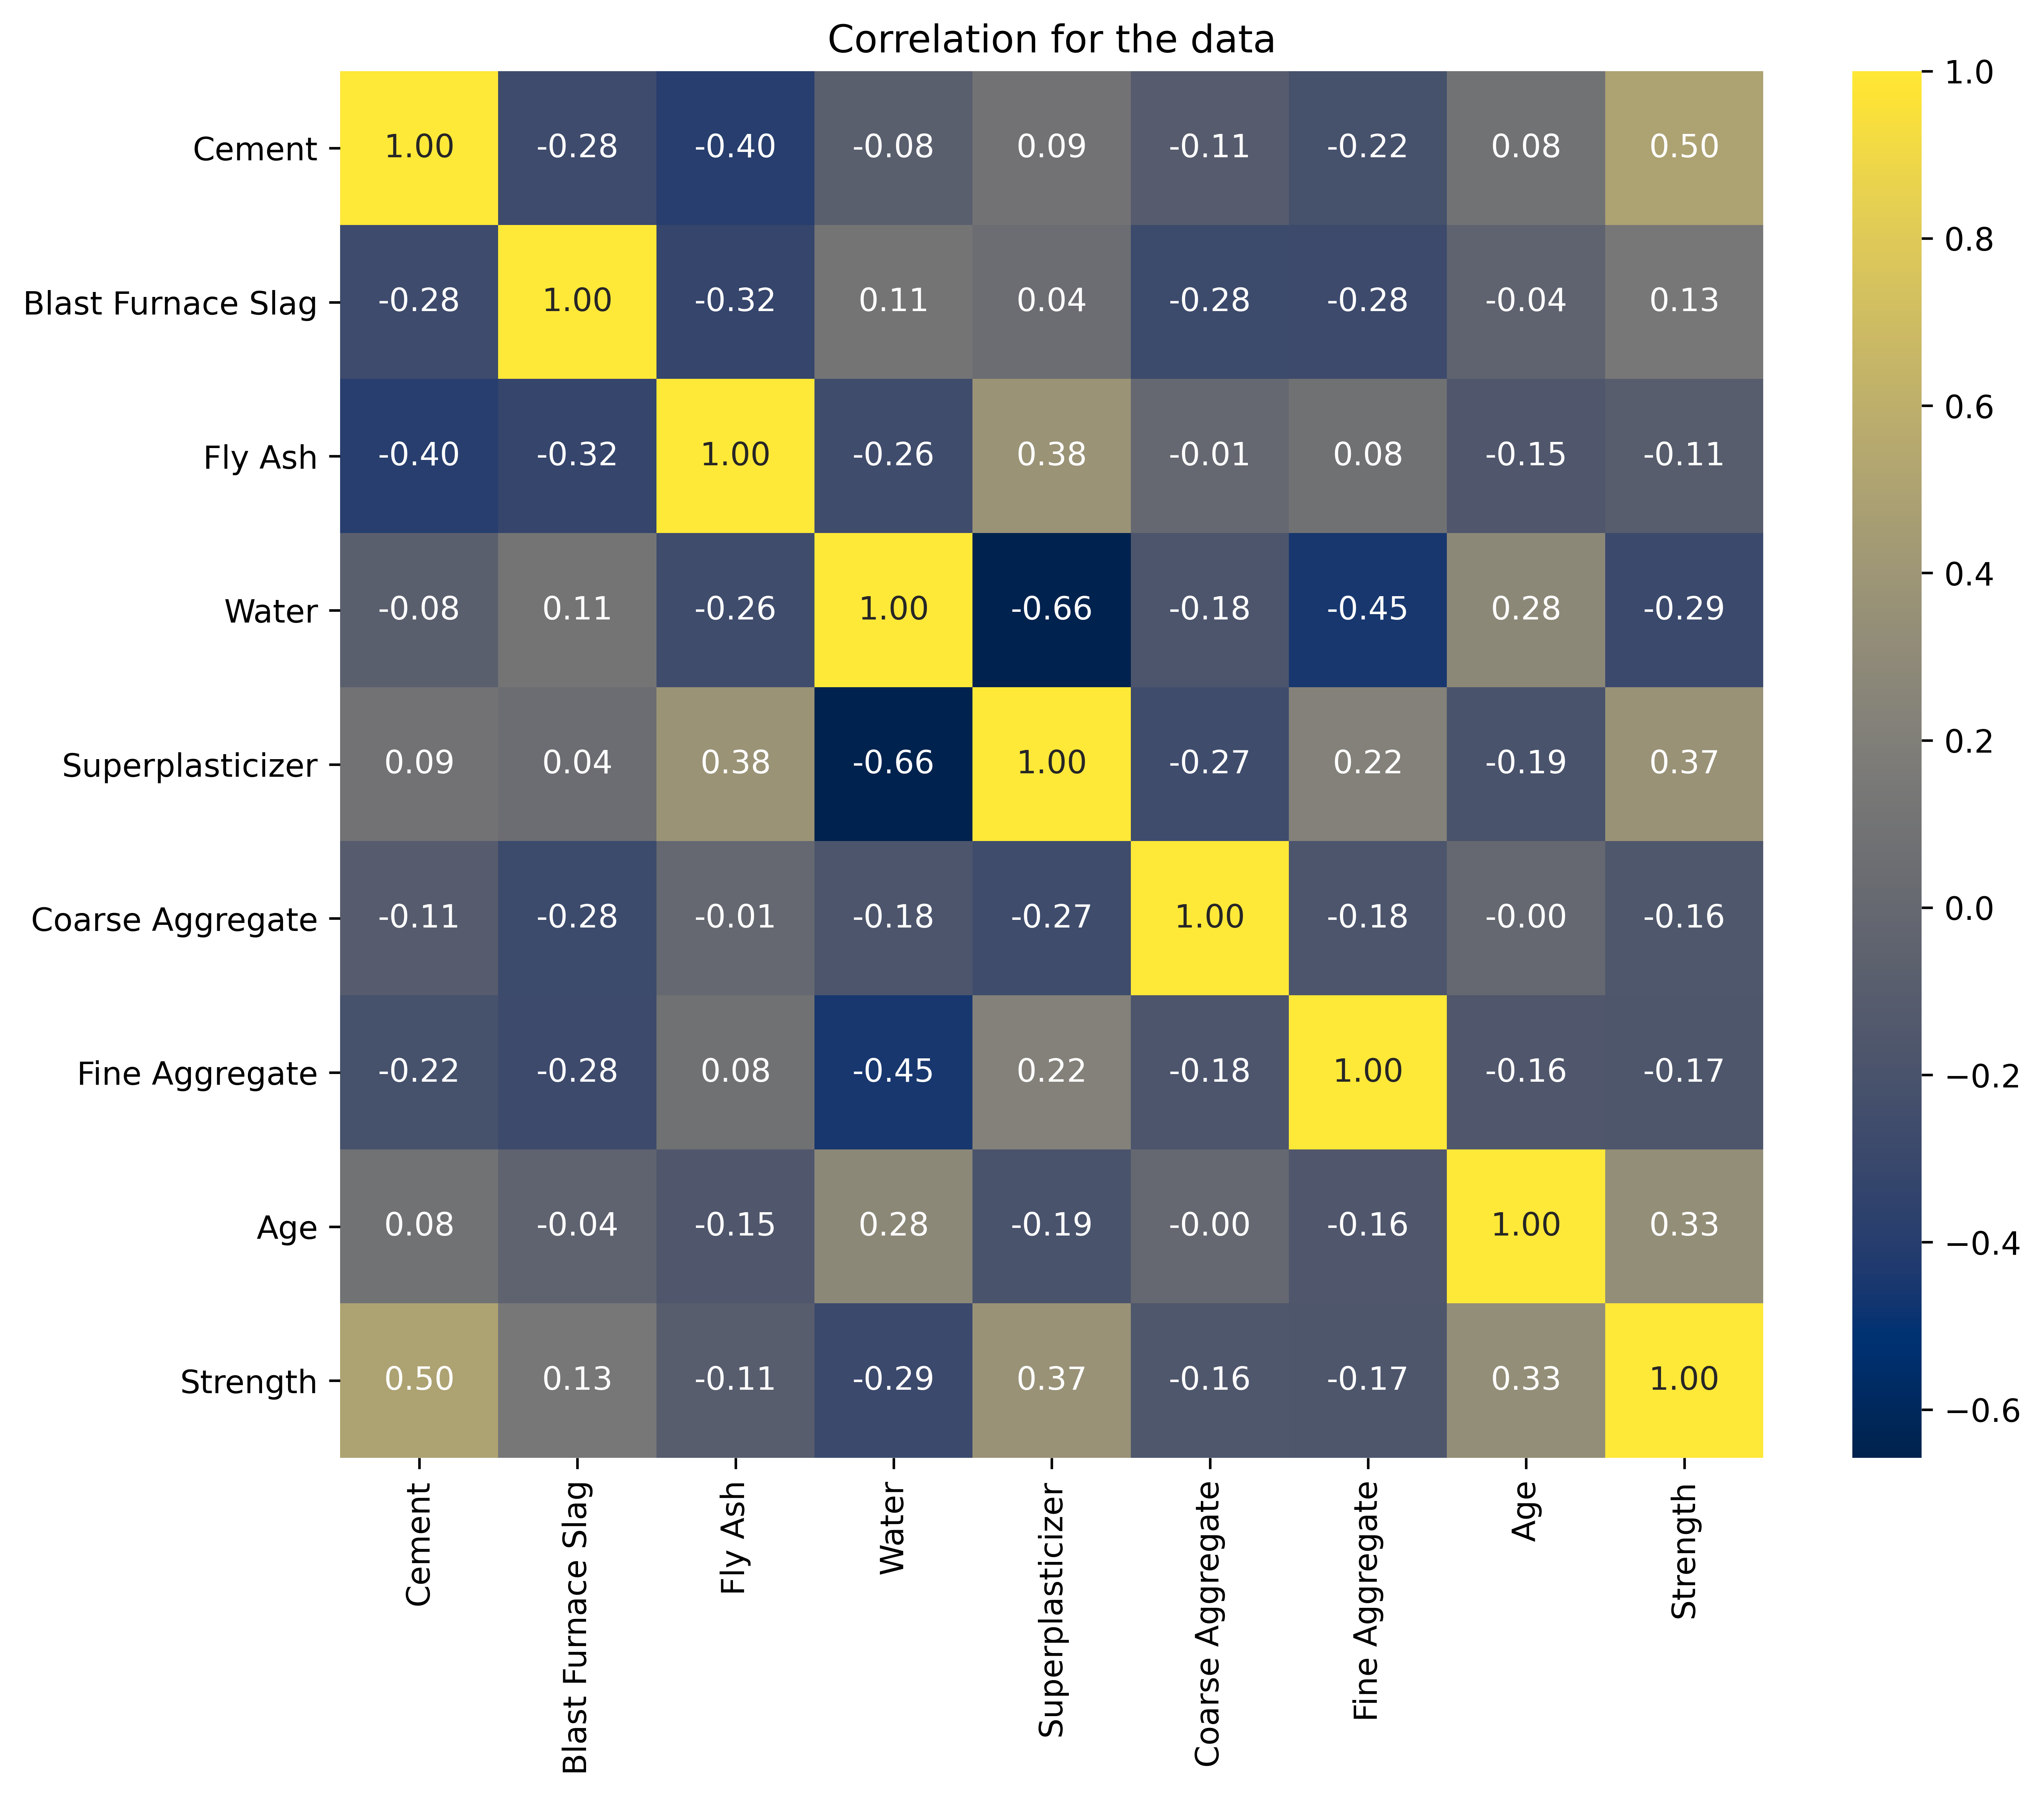

In [ ]:
def replace_outliers_with_mean(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column[(column<lower_bound) | (column>upper_bound)] = column.mean()

    return column

def remove_outliers_from_data(df, columns_to_fix):
    df[columns_to_fix] = df[columns_to_fix].apply(replace_outliers_with_mean)
    return df



def clean_data(df):
    ammount_of_null = int(df.isnull().sum().sum())
    if ammount_of_null > 0:
        print(f'The ammount of null values in the dataset - {ammount_of_null} ')
        df.dropna()
        # print("Null values removed")

    ammount_of_duplicates = df.duplicated().sum()
    if ammount_of_duplicates > 0:
        print(f'The ammount of duplicate values in the dataset - {ammount_of_duplicates} ')
        df.drop_duplicates()
        print("Duplicates removed")
    
    d1 = df
    plt.figure(figsize=(15, 10), dpi = 600)
    sns.boxenplot(d1=d1)
    plt.xticks(rotation=90)
    plt.title("Boxen-plot of the columns")
    plt.show()
    columns_with_outliers = ['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate', 'Strength']
    remove_outliers_from_data(df, columns_with_outliers)


    d2 = df
    plt.figure(figsize=(15, 10), dpi = 600)
    sns.boxenplot(d2=d2)
    plt.xticks(rotation=90)
    plt.title("Boxen-plot of the columns")
    plt.show()
    columns_with_outliers = ['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate', 'Strength']
    remove_outliers_from_data(df, columns_with_outliers)


    columns_with_outliers2 = ['Water', 'Superplasticizer', 'Age', 'Strength']
    remove_outliers_from_data(df, columns_with_outliers2)
    d3 = df
    plt.figure(figsize=(15, 10), dpi = 600)
    sns.boxenplot(d3=d3)
    plt.xticks(rotation=90)
    plt.title("Boxen-plot of the columns")
    plt.show()



def look_at_data_plots(df):
    # looking at the distributions 
    for columns in df:
        sns.kdeplot(df[columns], shade=True, color='red')
        plt.show()
        df[columns].hist()
        plt.show()


# reading the csv file 
df = pd.read_csv("C:/Users/andsa/Documents/ML/concrete_data.csv")  
#clean_data((df))


# Checking for correlation to remove columns 
#corr_matrix = df.corr()
#corr_matrix["Strength"]

def removing_data_based_on_correlation(df):
    plt.figure(figsize=(10, 8), dpi = 600)
    sns.heatmap(df.corr(), annot=True, cmap='cividis', fmt=".2f")
    plt.title("Correlation for the data")
    plt.show()
    df = df.drop(['Superplasticizer', 'Water'], axis = 1)
    return df









Assigning columns to the input and output variables X and y.

In [ ]:
# assigning the X and y values 
X = df[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df[['Strength']]

Importing libraries to split the data into a training and a test set, with 80 percent of the data used for training, and 20 percent used for testing. Also scaling the data, wich is important for all but the simple OLS. 

In [ ]:
# importing test metrics 
from sklearn.metrics import mean_squared_error, r2_score

# importing a splitter for the data 
from sklearn.model_selection import train_test_split

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scaling the data - think this won't allow the same pairs in test and train, scaling is important for the SGD regressor 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Creating and fitting a linear OLS and SGD model to the training data, to compare results. 

In [ ]:
# Doing an ordinary least squares regression -> OLS 
from sklearn.linear_model import LinearRegression
lin_reg_OLS = LinearRegression()
# fitting the OLS model to the training data
lin_reg_OLS.fit(X_train, y_train)


# Doing a stochastic gradient descent method -> SGD, with max interations of 1000, eta of .01, and a constant learning rate 
from sklearn.linear_model import SGDRegressor
lin_reg_SGD = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate="constant")
# fitting the SGD model to the training data 
lin_reg_SGD.fit(X_train_scaled, y_train)

Predicting strength values with both models, and printing metrics to gauge performance. 

In [ ]:
# Predicting strength values on the testing set for both models.  
y_pred_OLS = lin_reg_OLS.predict(X_test)
y_pred_SGD = lin_reg_SGD.predict(X_test_scaled)


# printing the metrics for the OLS model 
print("OLS Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_OLS), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_OLS), 2)}\n")


# printing the metrics for the SGD model 
print("SGD Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD), 2)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD), 2)}\n")

plt.scatter(y_test, y_pred_OLS, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


plt.scatter(y_test, y_pred_SGD, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Tuning the hyperparameters of a linear SGD model by using grid_search 

In [ ]:
# importing the grid search feature to optimize the params for SGD
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid with some values
params_for_grid = {
    "eta0": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],  # More values
    "max_iter": [500, 1000, 1500, 2000, 3000, 5000],  # Increased range
    "learning_rate": ["constant", "optimal", "invscaling", "adaptive"]
}

# Creating the SGD regressor
SGD = SGDRegressor(random_state=42)

# Perform Grid Search, dividing into 5 folds -> cv = 5, using all CPU cores to speed it up -> n_jobs = -1 
grid_search = GridSearchCV(SGD, params_for_grid, cv=5, n_jobs = -1)
grid_search.fit(X_train_scaled, y_train)

# Getting the best model from the grid search
best_SGD = grid_search.best_estimator_

# Predicting on the test set
y_pred_SGD_optimized = best_SGD.predict(X_test_scaled)


# Printing the results for the "optimal" SGD model and it's parameters 
print("Best Parameters:", grid_search.best_params_)


# printing the metrics for the tunged SGD model 
print("SGD Regression with hyperparameter tuning:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD_optimized), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD_optimized), 2)}\n")

plt.scatter(y_test, y_pred_SGD_optimized, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Creating a polynomial regressor to try to better fit the training data.

In [ ]:
# polynomial regression 
from sklearn.preprocessing import PolynomialFeatures


poly_features = PolynomialFeatures(degree = 3)
X_poly_train = poly_features.fit_transform(X_train_scaled)
X_poly_test = poly_features.transform(X_test_scaled)


lin_reg_for_poly = LinearRegression()
lin_reg_for_poly.fit(X_poly_train, y_train)

y_pred_poly = lin_reg_for_poly.predict(X_poly_test)

print("Simple polynomial Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_poly), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_poly), 2)}\n")


plt.scatter(y_test, y_pred_poly, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


Trying out a polynomial Lasso regression with hyperparameter tuning, going through multiple different degrees. 

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and Lasso regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', Lasso())             # Lasso regression
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],       # Degrees of the polynomial
    'regressor__alpha': [0.1, 0.5, 1.0, 10],  # Regularization strength for Lasso
    'regressor__fit_intercept': [True, False]  # Whether or not to fit the intercept term
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_lasso_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_lasso_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_lasso_grid), 4)}")


plt.scatter(y_test, y_pred_lasso_grid, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Doing the some for a RandomForestRegressor. (dropping it, didn't finnish after +45 mins)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and RandomForestRegressor
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', RandomForestRegressor())  # Random Forest regressor
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],          # Degrees of the polynomial
    'regressor__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'regressor__max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'regressor__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'regressor__min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs = -1)

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_rf_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_rf_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_rf_grid), 4)}")
